In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches 
import csv 
import numpy as np 
import seaborn as sns 
from sklearn.metrics import root_mean_squared_error
import ast 

In [3]:
TASC_VColor         = "#57B8FF"  
TASC_permute_VColor = "#2176AE" 
SC_VColor           = "#7ED957"  
RSC_VColor          = "#FF9F40"  
CIM_VColor          = "#E255A1"  

TASC_VColor_dark    = "#2D8DD6"  
TASC_permute_VColor_dark = "#155077"  
SC_VColor_dark      = "#4FA52F"  
RSC_VColor_dark     = "#CC6F1F"  
CIM_VColor_dark     = "#A83672"  

XLABEL_FS = 22 
XTICKS_FS = 20 
YTICKS_FS = 20 
LEGEND_FS = 22 
YLABEL_FS = 20 

In [4]:
START_TIME = 1970
INTERVENTION_TIME = 1989
STOP_TIME = 2001

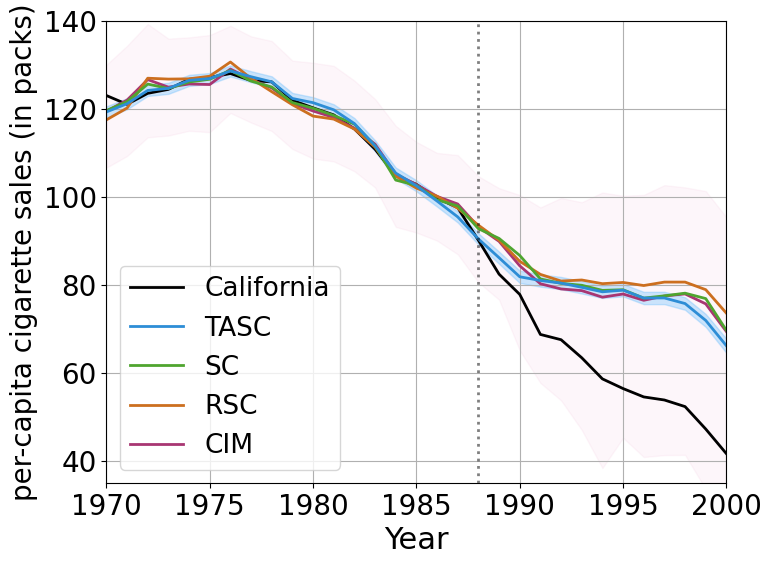

In [7]:
df_sc = pd.read_csv("resultLogsprop99/prop99_CaliforniaResults_aistats_nocim.csv")

list_cols = ["trueTarget", "pred_sc"]
        
for col in list_cols: 
    df_sc[col] = df_sc[col].apply(ast.literal_eval)

df_cim = pd.read_csv("resultLogsprop99/prop99_CaliforniaResults_aistats_just_cim.csv")

list_cols = ["trueTarget", "pred_cim", "cim_posterior_lower", "cim_posterior_upper"]
        
for col in list_cols: 
    df_cim[col] = df_cim[col].apply(ast.literal_eval)

df = pd.read_csv("resultLogsprop99/prop99_CaliforniaResults_aistats_includingcim.csv")


list_cols = ["trueTarget", "pred_tasc", "pred_rsc", "pred_sc", "pred_cim",
            "cim_posterior_lower", "cim_posterior_upper", "tasc_target_var_estimates", "R_tasc"]
        
for col in list_cols: 
    df[col] = df[col].apply(ast.literal_eval)


df["tasc_upper"] = df.apply(lambda row: row["pred_tasc"] + 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)
df["tasc_lower"] = df.apply(lambda row: row["pred_tasc"] - 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)

item_no = 0 
selected_row = df.iloc[item_no]
selected_row_sc = df_sc.iloc[item_no]
selected_row_cim = df_cim.iloc[item_no]

plt.figure(figsize=(8,6))
plt.plot(range(START_TIME, STOP_TIME), selected_row["trueTarget"], label='California', lw=2, color='black')
plt.plot(range(START_TIME, STOP_TIME), selected_row_cim["pred_cim"], label='CIM', lw=2, color=CIM_VColor_dark)
plt.fill_between(range(START_TIME, STOP_TIME), selected_row_cim["cim_posterior_lower"], selected_row_cim["cim_posterior_upper"], color=CIM_VColor, alpha=0.05)
plt.plot(range(START_TIME, STOP_TIME), selected_row["pred_rsc"], label='RSC', lw=2, color=RSC_VColor_dark)
plt.plot(range(START_TIME, STOP_TIME), selected_row_sc["pred_sc"], label='SC', lw=2, color=SC_VColor_dark)

plt.plot(range(START_TIME, STOP_TIME), selected_row["pred_tasc"], label='TASC', lw=2, color=TASC_VColor_dark)
plt.fill_between(range(START_TIME, STOP_TIME), selected_row["tasc_lower"], selected_row["tasc_upper"], color=TASC_VColor, alpha=0.3)


plt.axvline(x=INTERVENTION_TIME-1, color='black', alpha=0.5, lw=2, linestyle=':',)

handles, labels = plt.gca().get_legend_handles_labels()

order = ['California', 'TASC', 'SC', 'RSC', 'CIM']
ordered_handles = [handles[labels.index(label)] for label in order]

plt.legend(ordered_handles, order, loc='lower left', fontsize=LEGEND_FS-3)
plt.xlim([START_TIME, STOP_TIME-1])
plt.xlabel('Year', fontsize=XLABEL_FS)
plt.ylabel('per-capita cigarette sales (in packs)', fontsize=YLABEL_FS)
plt.xticks(fontsize=XTICKS_FS)
plt.yticks(fontsize=YTICKS_FS)
plt.ylim([35, 140])
plt.grid()
plt.show()

/var/folders/wr/nlkrnlkj13d3s1vtnlx0g7ym0000gn/T/ipykernel_10446/268650493.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rmse_filtered["x_dummy"] = "All Methods"  # single category


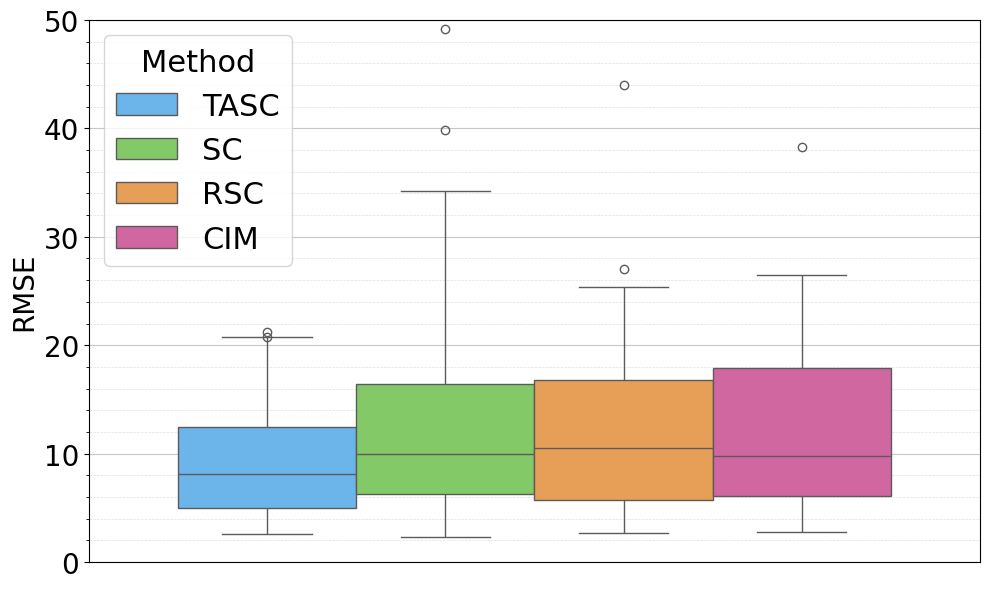

In [ ]:
df_cim = pd.read_csv("resultLogsprop99/vary_d_results_just_cim_aistats.csv")
list_cols_cim = ["trueTarget", "pred_cim", "cim_posterior_lower", "cim_posterior_upper",]
for col in list_cols_cim:
    df_cim[col] = df_cim[col].apply(ast.literal_eval)
pred_cols_cim = ['pred_cim']
for col in pred_cols_cim:
    df_cim["rmse_"+col] = df_cim.apply(
        lambda row: root_mean_squared_error(
            row["trueTarget"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

df = pd.read_csv("resultLogsprop99/prop99_vary_d_results_aistats.csv")
list_cols = ["trueTarget", "pred_tasc", "pred_rsc", "pred_sc", "tasc_target_var_estimates", "R_tasc"]
for col in list_cols: 
    df[col] = df[col].apply(ast.literal_eval)

pred_cols = ['pred_tasc', 'pred_rsc', 'pred_sc']
for col in pred_cols:
    df["rmse_"+col] = df.apply(
        lambda row: root_mean_squared_error(
            row["trueTarget"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

df_rmse = pd.DataFrame({"RMSE": np.concatenate([df["rmse_pred_tasc"], df["rmse_pred_sc"], df["rmse_pred_rsc"], df_cim["rmse_pred_cim"]]),
                        "Method": (["TASC"] * len(df["rmse_pred_tasc"]) + 
                                    ["SC"] * len(df["rmse_pred_sc"]) + 
                                    ["RSC"] * len(df["rmse_pred_rsc"]) + 
                                    ["CIM"] * len(df_cim["rmse_pred_cim"])
                        ),
                        "d": df["d_kalman"].tolist() * 4
                        })

plt.figure(figsize=(10, 6))
df_rmse_d2 = df_rmse[df_rmse["d"] == 2]
df_rmse_filtered = df_rmse[
    ((df_rmse["Method"] == "TASC") & (df_rmse["d"] == 2)) | 
    ((df_rmse["Method"] != "TASC") & (df_rmse["d"] == 2))
]
df_rmse_filtered["x_dummy"] = "All Methods"  # single category
sns.boxplot(
    data=df_rmse_filtered,
    x="x_dummy",
    y="RMSE",
    whis = [0, 95],
    hue="Method",
    palette={
        "TASC": TASC_VColor,
        "SC": SC_VColor,
        "RSC": RSC_VColor,
        "CIM": CIM_VColor
    },
)

plt.xlabel("")
plt.ylabel("RMSE", fontsize=YLABEL_FS)

plt.xticks([], [])
plt.yticks(fontsize=YTICKS_FS)
plt.ylim(0, 50)
plt.minorticks_on()
plt.tick_params(axis="x", which="minor", bottom=False, top=False)   
plt.tick_params(axis="y", which="minor", left=True, right=False)     

plt.grid(axis='y', which="major", linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(axis='y', which="minor", linestyle='--', linewidth=0.5, alpha=0.4)

plt.legend(loc='upper left', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS, title="Method")
plt.tight_layout()
plt.show()

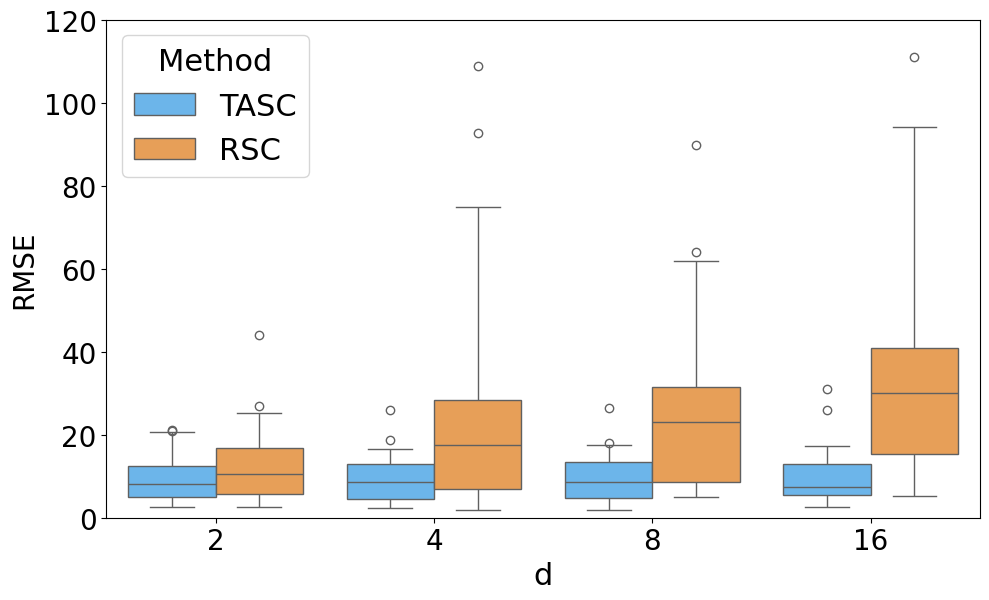

In [ ]:
df = pd.read_csv("resultLogsprop99/prop99_vary_d_results_aistats.csv")


list_cols = ["trueTarget", "pred_tasc", "pred_rsc", "pred_sc", "tasc_target_var_estimates", "R_tasc"]
        
for col in list_cols: 
    df[col] = df[col].apply(ast.literal_eval)

pred_cols = ['pred_tasc', 'pred_rsc']
for col in pred_cols:
    df["rmse_"+col] = df.apply(
        lambda row: root_mean_squared_error(
            row["trueTarget"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

df_rmse = pd.DataFrame({"RMSE": np.concatenate([df["rmse_pred_tasc"], df["rmse_pred_rsc"]]),
                        "Method": (["TASC"] * len(df["rmse_pred_tasc"]) + 
                                    ["RSC"] * len(df["rmse_pred_rsc"]) 
                        ),
                        "d": df["d_kalman"].tolist() * 2 
                        })

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_rmse,
    x="d",
    y="RMSE",
    whis = [0, 95],
    hue="Method",
    palette={
        "TASC": TASC_VColor,
        "RSC": RSC_VColor,
    },
)

plt.xlabel(r"d", fontsize=XLABEL_FS)
plt.ylabel("RMSE", fontsize=YLABEL_FS)

plt.xticks(fontsize=XTICKS_FS)
plt.yticks(fontsize=YTICKS_FS)

plt.legend(loc='upper left', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS, title="Method")
plt.tight_layout()
plt.ylim(0, 120)

plt.show()

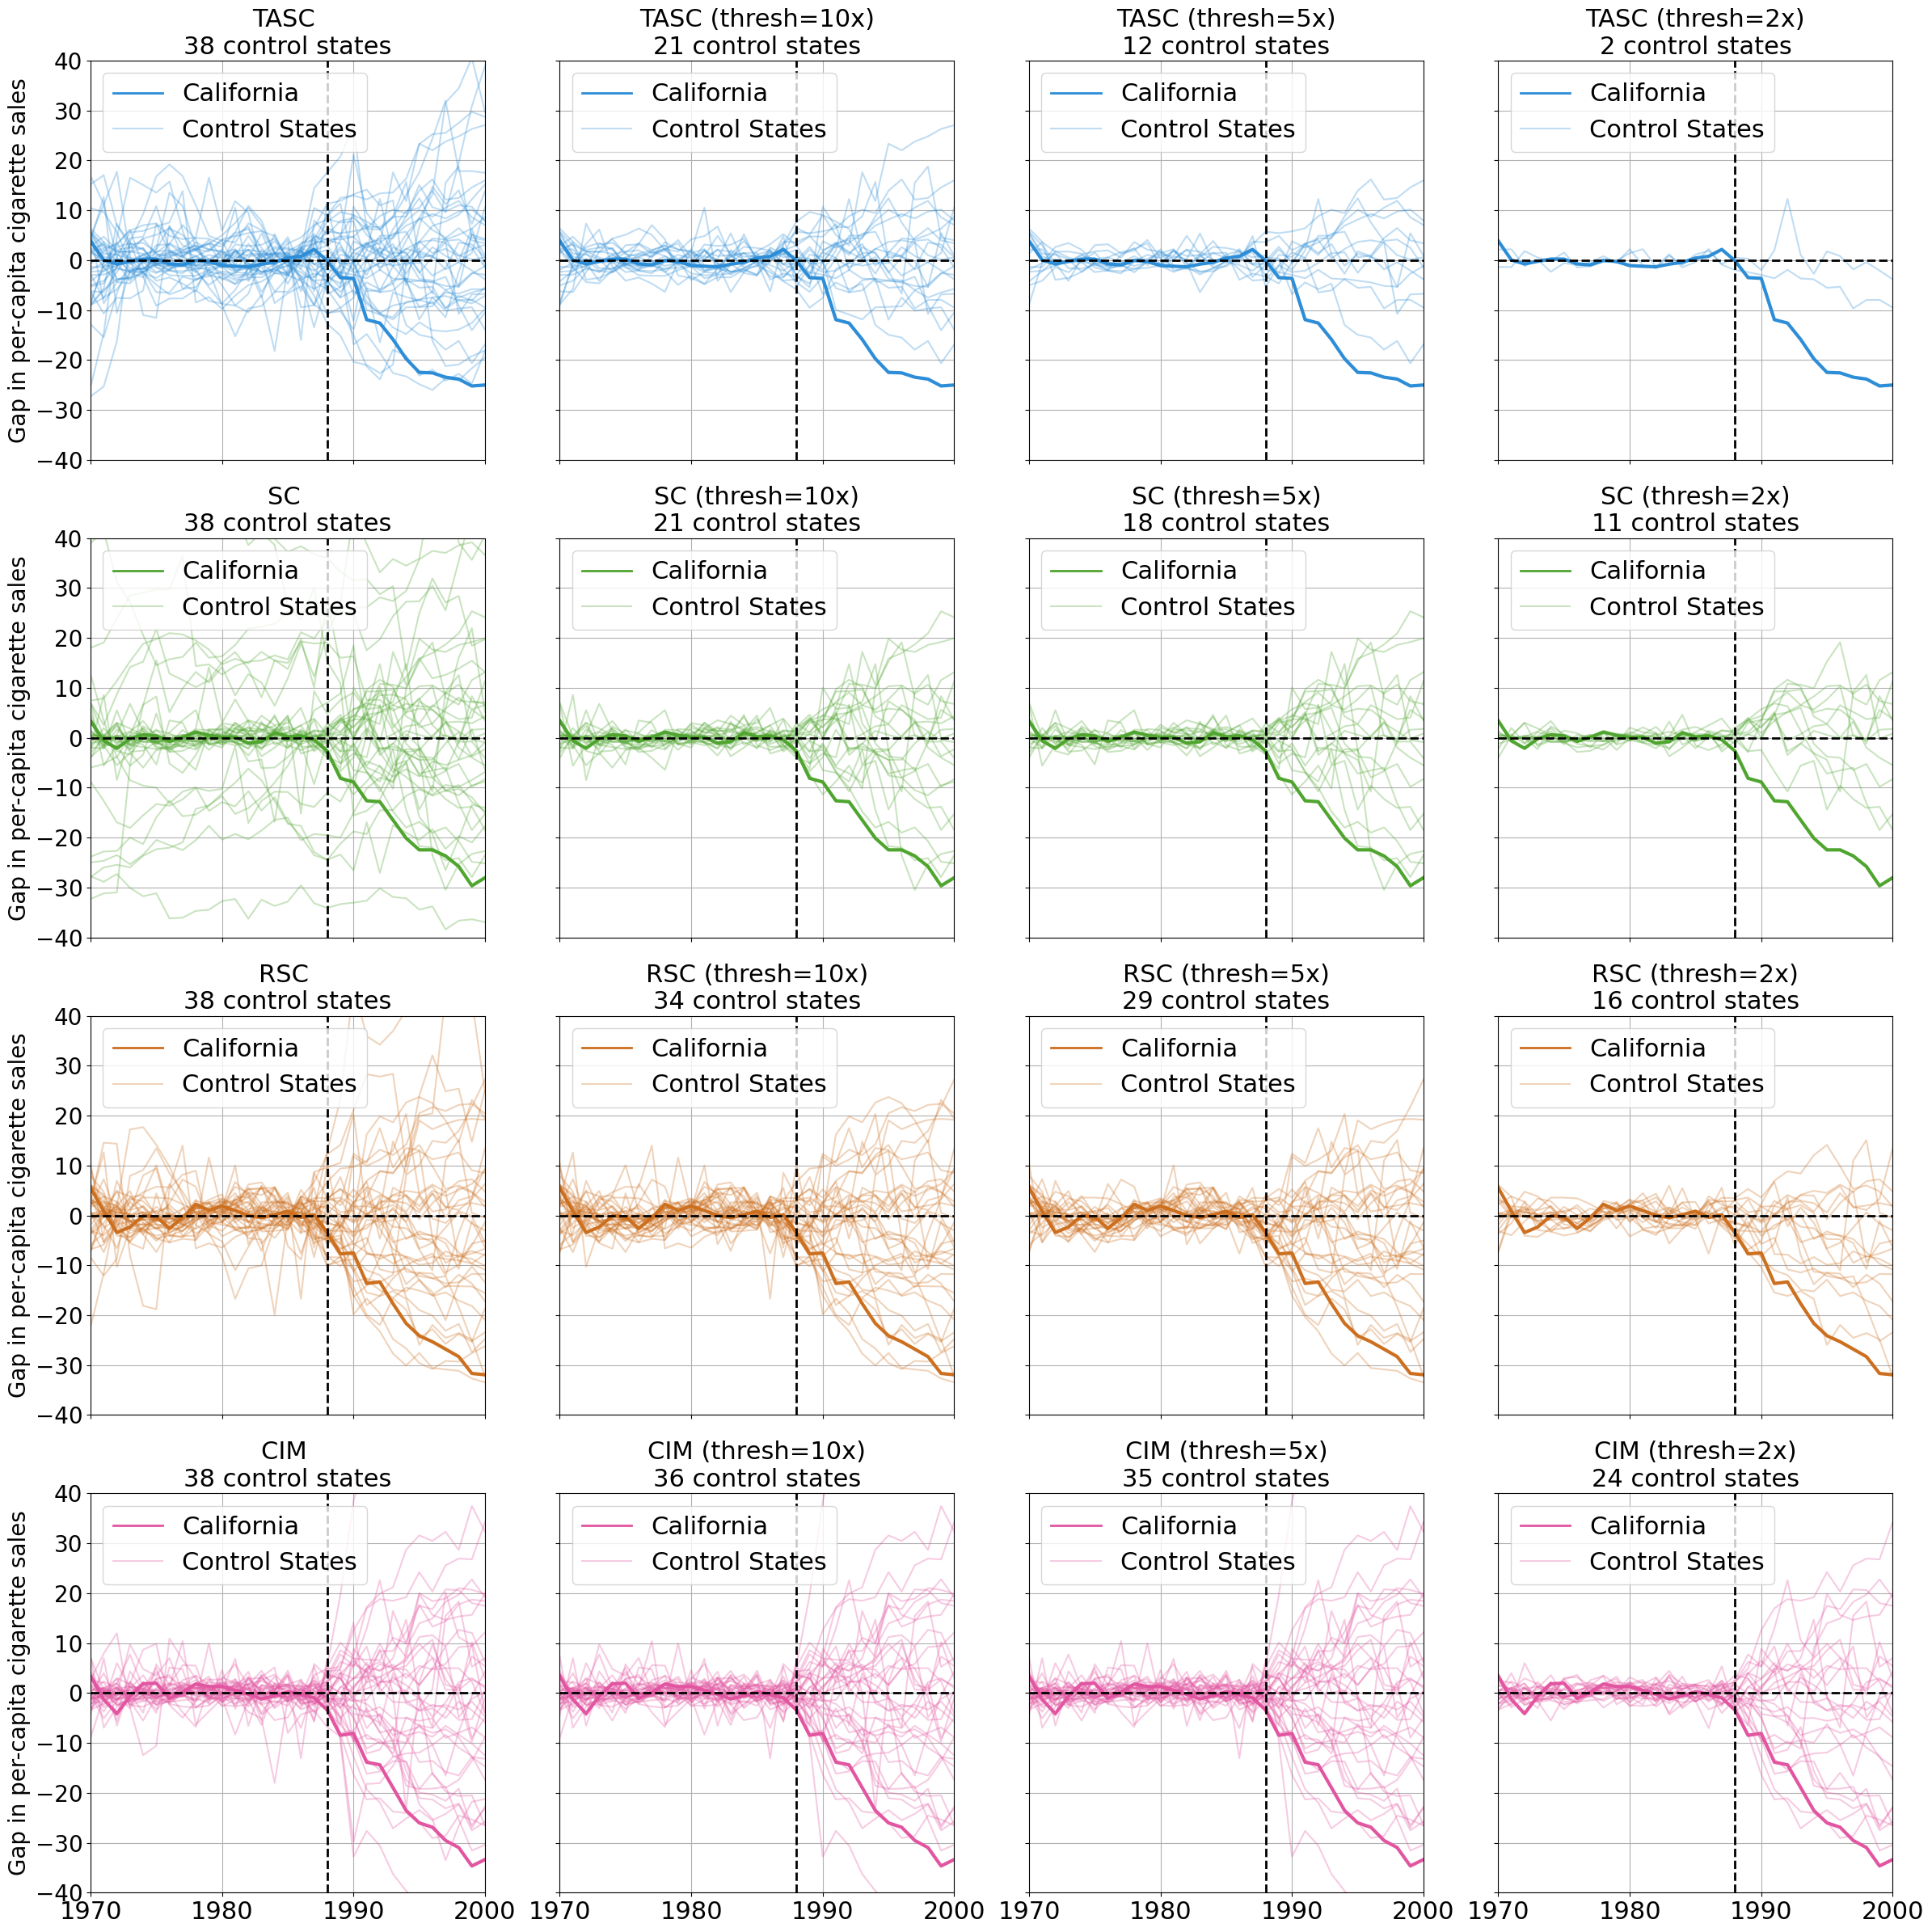

In [ ]:
import csv
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

arrays = []
file_name = "resultLogsprop99/prop99residualResults.csv"

T0 = INTERVENTION_TIME - START_TIME
tasc_pre_mse = 0
tasc_full_mse = 0
sc_mse = 0
rsc_mse = 0

with open(file_name, "r") as f:
    reader = csv.reader(f)
    header = next(reader)
    for row in reader:
        targetState, N1, N2, d_rsc, d_kalman = row[0], row[1], row[2], row[3], row[4]
        y_true = np.array(row[5:36], dtype=float)
        tasc_pre = np.array(row[36:67], dtype=float)
        y_sc = np.array(row[67:98], dtype=float)
        y_rsc = np.array(row[98:129], dtype=float)
        
        if targetState == 'California':
            tasc_pre_mse = mean_squared_error(y_true[:T0], tasc_pre[:T0])
            sc_mse = mean_squared_error(y_true[:T0], y_sc[:T0])
            rsc_mse = mean_squared_error(y_true[:T0], y_rsc[:T0])
            
        arrays.append((y_true, tasc_pre, y_sc, y_rsc, targetState))

california_mse = [tasc_pre_mse, sc_mse, rsc_mse]
MethodName = ["TASC", "SC", "RSC"]
MethodColor = [TASC_VColor_dark, SC_VColor_dark, RSC_VColor_dark]

arrays_cim = []
file_name_cim = "resultLogsprop99/prop99residualResults_just_cim_aistats.csv"
cim_mse = 0

with open(file_name_cim, "r") as f:
    reader = csv.reader(f)
    header = next(reader)
    for row in reader:
        targetState, N1, N2, d_rsc, d_kalman = row[0], row[1], row[2], row[3], row[4]
        y_true = np.array(row[5:36], dtype=float)
        y_cim = np.array(row[36:67], dtype=float)
        
        if targetState == 'California':
            cim_mse = mean_squared_error(y_true[:T0], y_cim[:T0])
        
        arrays_cim.append((y_true, y_cim, targetState))

california_mse_cim = [cim_mse]
MethodName_cim = ["CIM"]
MethodColor_cim = [CIM_VColor]

fig, axes = plt.subplots(4, 4, figsize=(24, 24), sharex=True, sharey=True)  
axes = axes.reshape(4, 4)  

# --- Plot TASC, RSC, SC ---
for i, idx in enumerate([1, 2, 3]):  
    for j, thresh in enumerate([100000, 10, 5, 2]):  
        ax = axes[i, j]
        timesteps = range(START_TIME, STOP_TIME)
        count = 0
        
        for test in arrays:
            if test[4] == 'California':
                ax.plot(timesteps, test[0] - test[idx], lw=3, alpha=1, color=MethodColor[idx-1])
            else:
                if mean_squared_error(test[0][:T0], test[idx][:T0]) < thresh * california_mse[idx-1]:
                    count += 1
                    ax.plot(timesteps, test[0] - test[idx], alpha=0.3, color=MethodColor[idx-1])
        
        custom_lines = [
            Line2D([0], [0], lw=2, color=MethodColor[idx-1], alpha=1, label='California'),
            Line2D([0], [0], color=MethodColor[idx-1], alpha=0.3, label='Control States')
        ]
        ax.legend(handles=custom_lines, loc='upper left', fontsize=LEGEND_FS)
        
        if int(thresh) < 1000:
            ax.set_title(f"{MethodName[idx-1]} (thresh={thresh}x)\n{count} control states", fontsize=LEGEND_FS)
        else: 
            ax.set_title(f"{MethodName[idx-1]} \n{count} control states", fontsize=LEGEND_FS)

        ax.grid(True)
        ax.axhline(0, color='black', alpha=1, linestyle='--', lw=2)
        ax.axvline(INTERVENTION_TIME-1, color='black', alpha=1, linestyle='--', lw=2)
        ax.set_ylim(-40, 40)
        ax.set_xlim(1970, 2000)

        if j == 0:
            ax.set_ylabel("Gap in per-capita cigarette sales", fontsize=YLABEL_FS)
            ax.tick_params(labelsize=YTICKS_FS)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

for j, thresh in enumerate([1000, 10, 5, 2]):
    ax = axes[3, j]
    timesteps = range(START_TIME, STOP_TIME)
    count = 0
    
    for test in arrays_cim:
        if test[2] == 'California':
            ax.plot(timesteps, test[0] - test[1], lw=3, alpha=1, color=MethodColor_cim[0])
        else:
            if mean_squared_error(test[0][:T0], test[1][:T0]) < thresh * california_mse_cim[0]:
                count += 1
                ax.plot(timesteps, test[0] - test[1], alpha=0.3, color=MethodColor_cim[0])
    
    custom_lines = [
        Line2D([0], [0], lw=2, color=MethodColor_cim[0], alpha=1, label='California'),
        Line2D([0], [0], color=MethodColor_cim[0], alpha=0.3, label='Control States')
    ]
    ax.legend(handles=custom_lines, loc='upper left', fontsize=LEGEND_FS)
    
    if int(thresh) < 100:
        ax.set_title(f"CIM (thresh={thresh}x)\n{count} control states", fontsize=LEGEND_FS)
    else: 
        ax.set_title(f"CIM \n{count} control states", fontsize=LEGEND_FS)
    
    ax.grid(True)
    ax.axhline(0, color='black', alpha=1, linestyle='--', lw=2)
    ax.axvline(INTERVENTION_TIME-1, color='black', alpha=1, linestyle='--', lw=2)
    ax.set_ylim(-40, 40)
    ax.set_xlim(1970, 2000)

    if j == 0:
        ax.tick_params(labelsize=YTICKS_FS)
        ax.set_ylabel("Gap in per-capita cigarette sales", fontsize=YLABEL_FS)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.tick_params(axis='x', labelsize=XLABEL_FS)

plt.tight_layout()
plt.show()